# Cellular Fourier Transform spectrum and temporal correlation of sepal growth

**Paper:** A. Fruleux, L. Hong, A. H. K. Roeder, C.-B. Li, A. Boudaoud, *Growth couples temporal and spatial fluctuations of tissue properties during morphogenesis*, PNAS 121(23):e2318481121 (2024); bioRxiv 2023.10.23.563640.

**Author code/data:** Zenodo record [11105905](https://doi.org/10.5281/zenodo.11105905) (CC-BY-4.0), archive `data_analysis.zip` (MATLAB code + bundled inputs + `Data.mat` results).

**Scope (one example).** This notebook recomputes, for **one** segmented sepal time series — the authors' own documented example `analyze_data('botero','bot-p1',0:24:72)` — the Cellular Fourier Transform (CFT) growth spectrum, its scaling exponent αt and amplitude, and the Kendall temporal correlation Gt of growth, then places the point on the paper's Fig. 6G master curve. This is a one-example demonstration, **not** a reproduction of the paper's dataset-level results.

**⚠ AI-assisted translation.** The authors released MATLAB code; the authors did **not** provide this Colab implementation. The pipeline below is a Python translation of the pinned MATLAB files (`load_data.m`, `cft_harmonics.m`, `cft_fourier.m`, `space_cor.m`, `time_cor.m`, `master_fit.m`), with each step cited to its source file. The executed example and the comparison against the authors' stored `Data.mat` results were validated, but untested behavior is not guaranteed.

（日本語）このノートブックは、上記論文の著者公開 MATLAB コード（Zenodo 11105905, data_analysis.zip）を Python に翻訳したものです。著者自身が使用例として示した `analyze_data('botero','bot-p1',0:24:72)`（1 個体の萼＝sepal 時系列）について、成長の Cellular Fourier Transform スペクトル（振幅・指数 αt）と Kendall 時間相関 Gt を再計算し、Fig. 6G のマスターカーブ上にプロットします。AI による翻訳であり、著者提供の Colab 実装ではありません。検証は著者の Data.mat の結果との比較によります。

## 1. Runtime selection — use a **CPU** runtime

**Runtime → Change runtime type → CPU** (no GPU needed; the pipeline is small linear algebra, numerical quadrature, and a 10 000-sample bootstrap on ~100 cells).

Expected duration: ≈5–10 min end to end (dominated by one 378 MB download). The 4.5 GB segmentation archive is **not** required.
（日本語）ランタイムは **CPU** を選択してください。所要時間は約 5〜10 分（378 MB のダウンロードが主）。4.5 GB のセグメンテーションアーカイブは不要です。

In [ ]:
import numpy as np, scipy, scipy.io as sio, matplotlib, zipfile, os, urllib.request, hashlib, sys
print('python', sys.version.split()[0])
print('numpy', np.__version__, '| scipy', scipy.__version__, '| matplotlib', matplotlib.__version__)

python 3.13.15
numpy 2.1.3 | scipy 1.16.3 | matplotlib 3.10.0


## 2. Input acquisition with provenance

We fetch the **pinned** Zenodo record 11105905 file `data_analysis.zip` and verify its MD5 (`76d6b9da3aedfd57b5d531eae7103243`, 378 201 107 bytes, from the record API metadata). The archive mixes MATLAB code with data, so it is downloaded and opened here in Colab, and only the files needed for the `bot-p1` example are extracted under `/content`.
（日本語）Zenodo の固定レコード 11105905 から `data_analysis.zip`（378 MB）をダウンロードし MD5 を検証します。コードとデータが混在するアーカイブのため、Colab 内でのみダウンロード・展開します。

In [ ]:
ZENODO_BASE = 'https://zenodo.org/api/records/11105905/files'
ZIP_NAME, ZIP_MD5, ZIP_SIZE = 'data_analysis.zip', '76d6b9da3aedfd57b5d531eae7103243', 378201107
zip_path = f'/content/{ZIP_NAME}'

def fetch_zenodo_file(key, dest):
    url = f'{ZENODO_BASE}/{key}/content'
    for attempt in range(3):
        try:
            urllib.request.urlretrieve(url, dest)
            return
        except Exception as e:
            print(f'attempt {attempt+1} failed: {e}')
            if attempt == 2:
                raise

if not os.path.exists(zip_path):
    fetch_zenodo_file(ZIP_NAME, zip_path)

size = os.path.getsize(zip_path)
md5 = hashlib.md5(open(zip_path, 'rb').read()).hexdigest()  # 378 MB fits in memory
assert size == ZIP_SIZE, (size, ZIP_SIZE)
assert md5 == ZIP_MD5, (md5, ZIP_MD5)
print(f'{ZIP_NAME}: {size} bytes, md5 {md5} — VERIFIED')

data_analysis.zip: 378201107 bytes, md5 76d6b9da3aedfd57b5d531eae7103243 — VERIFIED


Only the minimal selection is extracted to `/content`: the `bot-p1` example inputs (~6 MB), the authors' `Data.mat` results (used for validation and the master curve), and the archive readme.
（日本語）アーカイブからは、bot-p1 の入力（約 6 MB）と著者の計算済み結果 Data.mat、readme のみを展開します。

In [ ]:
zf = zipfile.ZipFile(zip_path)
members = [n for n in zf.namelist() if not n.endswith('/')]
print('entries:', len(members))

EXTRACT_PREFIXES = (
    'data_analysis/botero/bot-p1/',   # minimal example inputs
    'data_analysis/Data.mat',         # author-computed results (validation + master curve)
    'data_analysis/readme.txt',
)
for n in members:
    if n.startswith(EXTRACT_PREFIXES):
        zf.extract(n, '/content')
        print('extracted', n)

entries: 231


extracted data_analysis/Data.mat
extracted data_analysis/readme.txt
extracted data_analysis/botero/bot-p1/bot-p1.contour_cor.48.mat
extracted data_analysis/botero/bot-p1/bot-p1.contour_cor.72.mat
extracted data_analysis/botero/bot-p1/bot-p1.laplacien.0.mat
extracted data_analysis/botero/bot-p1/bot-p1.laplacien.48.mat
extracted data_analysis/botero/bot-p1/bot-p1.contour_cor.24.mat
extracted data_analysis/botero/bot-p1/bot-p1.laplacien.72.mat
extracted data_analysis/botero/bot-p1/bot-p1.transfer.mat
extracted data_analysis/botero/bot-p1/bot-p1.contour_cor.0.mat
extracted data_analysis/botero/bot-p1/bot-p1.laplacien.24.mat


## 3. Ported pipeline — `load_data.m`

Cell lineage transfer matrices `M{i}` map cells at time *i+1* onto cells at time *i*. Per time point the per-cell areal growth is `growth_i = (T_i · surf_{i+1}) / sqrt(surf_i) − sqrt(surf_i)` (load_data.m), cells with zero growth are filtered out, and the graph Laplacian is built from the author-provided weight matrix `W`: `L = I − sqrt(surf) · (W ./ rowsum(W)) ./ sqrt(surf)'`.
（日本語）著者の `load_data.m` を移植：細胞世代の転写行列から面積成長率を計算し、著者提供の重み行列 W からラプラシアン L を構成します。

In [ ]:
from scipy.stats import gmean

def load_data(fold, sepal, time):
    time = np.asarray(time)
    M = sio.loadmat(f'{BASE}/{fold}/{sepal}/{sepal}.transfer.mat')['M']  # (nT-1,1) cell
    if np.diff(time).mean() == 12:  # pair products (load_data.m); bot-p1 uses dt=24
        M = np.array([M[i, 0] @ M[i + 1, 0] for i in range(0, M.shape[0], 2)])
        time = np.arange(time[0], time[-1] + 1, 24)
    transfer = [np.atleast_2d(m) for m in M[:, 0]]
    out = {'transfer': transfer, 'time': time}
    l = len(time)
    out['surf_area'], out['liste'], out['W'] = [None] * l, [None] * l, [None] * l
    for i, t in enumerate(time):
        cc = sio.loadmat(f'{BASE}/{fold}/{sepal}/{sepal}.contour_cor.{t}.mat')
        lp = sio.loadmat(f'{BASE}/{fold}/{sepal}/{sepal}.laplacien.{t}.mat')
        out['liste'][i] = cc['liste'].ravel()
        out['W'][i] = lp['W']
        out['surf_area'][i] = lp['csurf'].ravel()
    l = len(time) - 1
    out['growth'], out['L'] = [None] * l, [None] * l
    for i in range(l):
        g = (out['transfer'][i] @ out['surf_area'][i + 1]) / np.sqrt(out['surf_area'][i])
        I = g != 0
        out['liste'][i] = out['liste'][i][I]
        out['W'][i] = out['W'][i][np.ix_(I, I)]
        out['surf_area'][i] = out['surf_area'][i][I]
        g = g[I] - np.sqrt(out['surf_area'][i])
        out['growth'][i] = g
        Nc = out['W'][i].shape[0]
        s = np.sqrt(out['surf_area'][i])
        out['L'][i] = np.eye(Nc) - s[:, None] * (out['W'][i] / out['W'][i].sum(axis=1, keepdims=True)) / s[None, :]
    return out

BASE = '/content/data_analysis'
print('load_data port ready')

load_data port ready


## 4. CFT harmonics and spectrum — `cft_harmonics.m`, `cft_fourier.m`

The CFT harmonics are the eigenvectors of the tissue Laplacian `L` (via SVD, eigenvalues sorted ascending, first-row sign fixed). The wave numbers are `q = sqrt(−1 + (1−f)^(−2/3)) / Nsigma` with `Nsigma = 5` (cft_harmonics.m). The CFT of the growth field is `Uᵀ·growth / sqrt(Σ surf)` (cft_fourier.m); its first coefficient is the tissue-mean growth `Mgrowth`.
（日本語）CFT 調和関数はラプラシアン L の固有ベクトル（SVD、昇順ソート、符号固定）、波数は q=√(−1+(1−f)^(−2/3))/Nsigma（Nsigma=5）。CFT スペクトルは Uᵀ·growth/√(Σsurf)、第 1 係数が組織平均成長率。

In [ ]:
def cft_harmonics(V, Nsigma=5):
    l = len(V['L'])
    V['hL'], V['q'], V['U'] = [None] * l, [None] * l, [None] * l
    for i, L in enumerate(V['L']):
        Ufull, S, Vh = np.linalg.svd(L)
        E = S  # singular values, sorted descending; = |eigenvalues| of the symmetric PSD L
        order = np.argsort(E)          # ascending, as in full_eigen.m
        E = E[order]
        # MATLAB [~, ev, eigenvectors] = svd(full(L)) binds the THIRD output (right
        # singular vectors); verified against Data.mat BOT{1} Mgrowth (probe3_uv).
        U = Vh.T[:, order]
        signs = np.sign(U[0]); signs[signs == 0] = 1
        V['hL'][i] = E
        V['U'][i] = U * signs[None, :]
        q = np.sqrt(-1.0 + (1.0 - E) ** (-2.0 / 3.0)) / Nsigma
        assert np.all(np.isfinite(q)) and np.max(np.abs(q.imag if np.iscomplexobj(q) else 0)) < 1e-12, 'unexpected eigenvalue range'
        V['q'][i] = np.real(q)
    return V

def cft_fourier(V, signal):
    return [V['U'][i].T @ signal[i] / np.sqrt(V['surf_area'][i].sum()) for i in range(len(signal))]

print('cft ports ready')

cft ports ready


## 5. Space correlations αt, SD — `space_cor.m`

For each time point the CFT spectrum `|CFT(q)|²` is compared to the prediction `B·q^(−α)` with `q` rescaled by its geometric mean. The scaling exponent α is the root of `f(α) = Σ log(Q)·Q^α·|CFT|²` (monotone ⇒ unique root; MATLAB `fzero`), and the posterior over α and over the amplitude C is integrated on a∈[0,2] to obtain means, standard deviations and 90% credible intervals. MATLAB's `gammainc(x, a)` is the regularized lower incomplete gamma `P(a,x)` = `scipy.special.gammainc(a,x)`.
（日本語）各時点のスペクトルからスケーリング指数 α と成長ゆらぎの標準偏差 SD を、ベイズ事後分布の積分で推定します。

In [ ]:
from scipy.optimize import brentq
from scipy.integrate import quad
from scipy.special import gammainc, gammaln

def _root_of(fn, x0, lo, hi):
    """Brent root with a bracket scan (adaptation of MATLAB fzero)."""
    xs = np.linspace(lo, hi, 401)
    vals = np.array([fn(x) for x in xs])
    for j in np.where(vals[:-1] * vals[1:] < 0)[0]:
        return brentq(fn, xs[j], xs[j + 1], xtol=1e-12)
    # no sign change: emulate MATLAB fzero(f,1) followed by the 0..2 clamp
    if fn(lo) > 0:
        return float(lo)
    if fn(hi) < 0:
        return float(hi)
    return float(np.clip(x0, lo, hi))

def space_cor(sepal):
    out = dict(sepal)
    l = len(sepal['CFTgrowth'])
    sc = {k: np.zeros(l) for k in ['alpha', 'alphamean', 'alphastd', 'SD', 'SD_mean', 'SD_std']}
    sc['CIalpha'], sc['CISD'] = np.zeros((l, 2)), np.zeros((l, 2))
    for i in range(l):
        q = sepal['q'][i][2:]
        CFT2 = sepal['CFTgrowth'][i][2:] ** 2
        lq = len(q)
        Q = q / gmean(q)   # scipy.stats.gmean, = MATLAB geomean
        f = lambda a: np.log(Q) @ (Q ** a * CFT2)
        alpha = _root_of(f, 1.0, 0.0, 2.0)
        Ec = 1.0 / np.mean(Q ** alpha * CFT2)
        Cc = 1.0 / (2 * CFT2.sum())
        Ka = lambda a: (np.mean(CFT2 * Q ** a) * Ec) ** (-1 - lq / 2)
        KSD1 = lambda a: np.sqrt(np.mean(CFT2 * Q ** a) * (Q ** (-a)).sum()) * (np.mean(CFT2 * Q ** a) * Ec) ** (-1 - lq / 2)
        KSD2 = lambda a: np.mean(CFT2 * Q ** a) * (Q ** (-a)).sum() * (np.mean(CFT2 * Q ** a) * Ec) ** (-1 - lq / 2)
        Z = quad(Ka, 0, 2)[0]
        m1 = quad(lambda a: a * Ka(a), 0, 2)[0] / Z
        m2 = quad(lambda a: a ** 2 * Ka(a), 0, 2)[0] / Z
        MSD1 = quad(KSD1, 0, 2)[0] / Z * np.exp(0.5 * np.log(lq / 2) + gammaln(0.5 + lq / 2) - gammaln(1 + lq / 2))
        MSD2 = quad(KSD2, 0, 2)[0] / Z
        PDFa = lambda a: quad(Ka, 0, a)[0] / Z
        PDFC = lambda C: quad(lambda a: Ka(a) * gammainc(lq / 2, C * np.sum(CFT2 * Q ** a) * (Q ** (-a)).sum()), 0, 2)[0] / Z
        aM, aP = sorted([_root_of(lambda a: PDFa(a) - 0.05, alpha, 0.0, 2.0),
                         _root_of(lambda a: PDFa(a) - 0.95, alpha, 0.0, 2.0)])
        Cmed = _root_of(lambda C: PDFC(C) - 0.5, Cc, 1e-12, 100 * Cc)
        CP = _root_of(lambda C: PDFC(C) - 0.95, 2 * Cc, 1e-12, 100 * Cc)
        CM = _root_of(lambda C: PDFC(C) - 0.05, Cc, 1e-12, 100 * Cc)
        sc['alpha'][i] = _root_of(lambda a: PDFa(a) - 0.5, alpha, 0.0, 2.0)
        sc['alphamean'][i], sc['alphastd'][i] = m1, np.sqrt(m2 - m1 ** 2)
        sc['CIalpha'][i] = [aM, aP]
        sc['SD'][i], sc['SD_mean'][i], sc['SD_std'][i] = 1 / np.sqrt(2 * Cmed), MSD1, np.sqrt(MSD2 - MSD1 ** 2)
        sc['CISD'][i] = [1 / np.sqrt(2 * CP), 1 / np.sqrt(2 * CM)]
    out['space_cor'] = sc
    return out

print('space_cor port ready')

space_cor port ready


## 6. Temporal correlation Gt — `time_cor.m`

Kendall's τ between the growth of cells at time *i* ("G0") and the growth of their descendants at time *i+1* ("G1", propagated through the lineage transfer matrix `T0`), computed on **10 000 bootstrap resamples**. `r` is the bootstrap median (MATLAB `sbs(5000)`), `ci` the 5–95% interval. The only change from the original: the bootstrap RNG is seeded (`default_rng(0)`) for reproducibility, whereas MATLAB `bootstrp` is unseeded — so Gt agrees with `Data.mat` only to within bootstrap noise.
（日本語）時点 i と i+1 の細胞成長（子孫は転写行列で伝播）の Kendall 相関を 10000 回のブートストラップで推定します。乱数は再現性のため固定シードに変更しています（元コードはシードなし）。

In [ ]:
from scipy.stats import kendalltau

def time_cor(sepal, nboot=10000, seed=0):
    out = dict(sepal)
    l = len(sepal['growth'])
    tc = {'G0': [None] * (l - 1), 'G1': [None] * (l - 1),
          'r': np.zeros(l - 1), 'ci': np.zeros((l - 1, 2)),
          'mean': np.zeros(l - 1), 'std': np.zeros(l - 1)}
    rng = np.random.default_rng(seed)
    for i in range(l - 1):
        T0 = sepal['transfer'][i].copy()
        T1 = sepal['transfer'][i + 1]
        I0 = T0.sum(axis=1) != 0
        I1 = T1.sum(axis=1) != 0          # rows of T1 = cells at time i+1 (time_cor.m)
        T0 = T0[np.ix_(I0, I1)]
        I0 = T0.sum(axis=1) != 0
        T0 = T0[I0, :]
        G0 = (sepal['L'][i] @ sepal['growth'][i]) / np.sqrt(sepal['surf_area'][i])
        G1 = (T0 @ ((sepal['L'][i + 1] @ sepal['growth'][i + 1]) * np.sqrt(sepal['surf_area'][i + 1]))) / (T0 @ sepal['surf_area'][i + 1])
        G0 = G0[I0]
        tc['G0'][i], tc['G1'][i] = G0, G1
        n = len(G0)
        bs = np.empty(nboot)
        for b in range(nboot):
            idx = rng.integers(0, n, n)
            bs[b] = kendalltau(G0[idx], G1[idx]).statistic
        sbs = np.sort(bs)
        tc['r'][i] = sbs[4999]          # MATLAB sbs(5000) of 10000
        tc['ci'][i] = [sbs[499], sbs[9499]]
        tc['mean'][i], tc['std'][i] = bs.mean(), bs.std(ddof=1)
    out['time_cor'] = tc
    return out

print('time_cor port ready')

time_cor port ready


## 7. Run the pipeline on the minimal example `bot-p1`

Equivalent of the authors' `analyze_data('botero','bot-p1',0:24:72)` (analyze_data.m).
（日本語）著者の使用例に沿って bot-p1 時系列へパイプラインを実行します。

In [ ]:
bot = load_data('botero', 'bot-p1', np.arange(0, 72 + 1, 24))
print('time points:', bot['time'])
print('cells per time (after zero-growth filter):', [len(g) for g in bot['growth']])
bot = cft_harmonics(bot, 5)
bot['CFTgrowth'] = cft_fourier(bot, bot['growth'])
bot['Mgrowth'] = np.array([c[0] for c in bot['CFTgrowth']])
print('Mgrowth (1/d):', np.round(bot['Mgrowth'].real, 4))
bot = space_cor(bot)
bot = time_cor(bot, nboot=10000, seed=0)
print('alpha  (most probable):', np.round(bot['space_cor']['alpha'], 4))
print('SD     (most probable):', np.round(bot['space_cor']['SD'], 4))
print('Gt     (bootstrap median):', np.round(bot['time_cor']['r'], 4))

time points: [ 0 24 48 72]
cells per time (after zero-growth filter): [110, 106, 199]
Mgrowth (1/d): [0.8611 1.297  1.0117]


alpha  (most probable): [1.6303 1.0693 1.3089]
SD     (most probable): [0.5415 0.5987 0.3848]
Gt     (bootstrap median): [ 0.4714 -0.0667]


## 8. Validation against the authors' stored results (`Data.mat`, `BOT{1}` = bot-p1)

Deterministic quantities (Mgrowth, α, SD) should match closely; the bootstrap-based Gt should match to within bootstrap noise.
（日本語）決定論的な量（Mgrowth・α・SD）は Data.mat の格納値とよく一致し、ブートストラップ由来の Gt は統計ノイズの範囲で一致します。

In [ ]:
import pandas as pd

D = sio.loadmat('/content/data_analysis/Data.mat', squeeze_me=True, struct_as_record=False)
BOT = np.atleast_1d(D['BOT']).ravel()
auth = BOT[0]  # BOT{1} = bot-p1 (order of analyze_all_data.m)
sc_a, tc_a = auth.space_cor, auth.time_cor

rows = [('Mgrowth', np.array(auth.Mgrowth).ravel().real, np.array(bot['Mgrowth']).ravel().real)]
for k in ['alpha', 'alphamean', 'alphastd', 'SD', 'SD_mean']:
    rows.append((f'space_cor.{k}', np.array(getattr(sc_a, k)).ravel(), bot['space_cor'][k]))
for k in ['r', 'mean', 'std']:
    rows.append((f'time_cor.{k}', np.array(getattr(tc_a, k)).ravel(), bot['time_cor'][k]))

tab = pd.DataFrame([(n, a[:3], p[:3], np.max(np.abs(np.asarray(a[:3], float) - np.asarray(p[:3], float))))
                    for n, a, p in rows],
                   columns=['quantity', 'Data.mat BOT{1}', 'this notebook', 'max abs diff'])
tab.round(4)

,quantity,Data.mat BOT{1},this notebook,max abs diff
0,Mgrowth,"[0.8610914925793042, 1.2970470336862507, 1.011...","[0.8610914925793043, 1.2970470336862499, 1.011...",0.0000
1,space_cor.alpha,"[1.6302849329857971, 1.06930571400952, 1.30890...","[1.6302849329860958, 1.0693057140090245, 1.308...",0.0000
2,space_cor.alphamean,"[1.6265799827055623, 1.0728022772595227, 1.311...","[1.626579982705792, 1.0728022772590267, 1.3112...",0.0000
3,space_cor.alphastd,"[0.1789637967329116, 0.16265484857229703, 0.12...","[0.17896379673289547, 0.16265484857221923, 0.1...",0.0000
4,space_cor.SD,"[0.5414806618598701, 0.5986625676730901, 0.384...","[0.5414806618598823, 0.5986625676730766, 0.384...",0.0000
5,space_cor.SD_mean,"[0.5403934691622315, 0.5967885055007086, 0.384...","[0.5403934691622244, 0.5967885055007072, 0.384...",0.0000
6,time_cor.r,"[0.47334410339256866, -0.06803594351732992]","[0.4713750668806849, -0.06666666666666667]",0.0020
7,time_cor.mean,"[0.4694700323320785, -0.06813630837900436]","[0.4682694362619848, -0.06572506161590135]",0.0024
8,time_cor.std,"[0.07841553532092721, 0.08111252656423047]","[0.07888799376037899, 0.0819064665756297]",0.0008


## 9. The CFT growth spectrum (Fig. 3-style view)

Spectrum `|CFTgrowth|` vs wave number `q` for the last two time points, with the fitted power law `B·q^(−α/2)` (α = most probable exponent; B and normalization as in fig3.m).
（日本語）成長の CFT スペクトル（図 3 相当）とべき乗フィット。

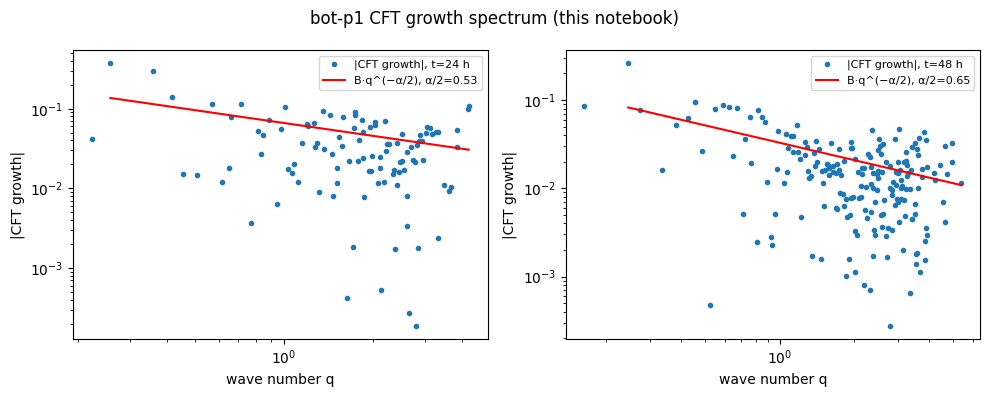

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, n in zip(axes, [len(bot['growth']) - 2, len(bot['growth']) - 1]):
    q = bot['q'][n][1:]
    spec = np.abs(bot['CFTgrowth'][n][1:])
    a = bot['space_cor']['alpha'][n] / 2
    B = bot['space_cor']['SD'][n]
    q3 = bot['q'][n][2:]
    ax.plot(q, spec, '.', label=f'|CFT growth|, t={bot["time"][n]} h')
    qq = np.logspace(np.log10(q3.min()), np.log10(q3.max()), 100)
    ax.plot(qq, B * qq ** (-a) / np.sqrt((q3 ** (-a)).sum()), 'r-', label=f'B·q^(−α/2), α/2={a:.2f}')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('wave number q'); ax.set_ylabel('|CFT growth|')
    ax.legend(fontsize=8)
fig.suptitle('bot-p1 CFT growth spectrum (this notebook)')
fig.tight_layout(); plt.show()

## 10. Placement on the Fig. 6G master curve — `master_fit.m`

Following fig6_2.m / residual.m: x = 0.25·(2−α)·Mgrowth per interval, y = Gt (bootstrap mean). The Bayesian linear fit b0, b1 is computed over **all 15 series' stored results** in `Data.mat` (exactly the input master_fit.m consumes), and our recomputed bot-p1 points are overlaid. The θ-integral is evaluated on a dense grid (trapezoid) instead of MATLAB's adaptive `integral` — a documented adaptation.
（日本語）x=0.25·(2−α)·Mgrowth、y=Gt として、Data.mat の全 15 系列の格納値で master_fit.m と同じベイズ線形フィットを行い、再計算した bot-p1 の点を重ねます。

master-fit points: 42
master fit: Gt = -1.866·x + 0.596  (std 0.149, 0.024)


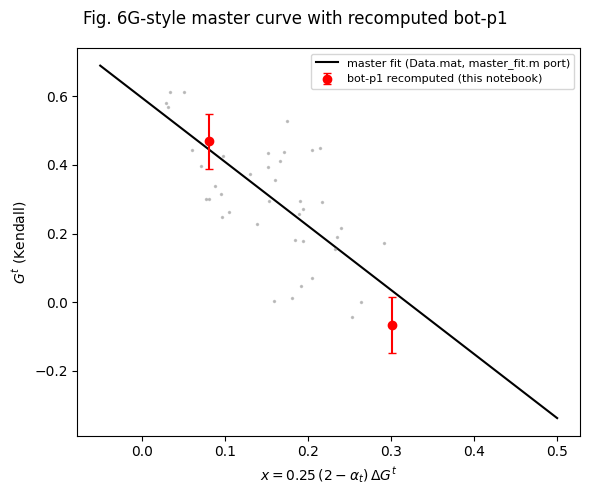

In [ ]:
series = {'BOT': BOT, 'MAD': np.atleast_1d(D['MAD']).ravel(), 'SPR': np.atleast_1d(D['SPR']).ravel(),
          'WT1': np.atleast_1d(D['WT1']).ravel(), 'WT2': np.atleast_1d(D['WT2']).ravel()}

X, SX, Y, SY = [], [], [], []
for arr in series.values():
    for s in np.atleast_1d(arr):
        mg = np.array(s.Mgrowth).ravel().real
        X.append(0.25 * (2 - np.array(s.space_cor.alphamean).ravel()[:-1]) * mg[:-1])
        SX.append(0.25 * np.array(s.space_cor.alphastd).ravel()[:-1] * mg[:-1])
        Y.append(np.array(s.time_cor.mean).ravel())
        SY.append(np.array(s.time_cor.std).ravel())
X, SX, Y, SY = map(np.concatenate, (X, SX, Y, SY))
print('master-fit points:', len(X))

th = np.pi * np.linspace(-0.999, -0.001, 4000)   # θ ∈ (−π, 0), tan θ < 0
den = np.tan(th)[:, None] ** 2 * SX ** 2 + SY ** 2
a_t = (1.0 / den).sum(axis=1)
b_t = ((np.tan(th)[:, None] * X - Y) / den).sum(axis=1)
arg0 = -0.5 * (np.log(den).sum(axis=1) + ((np.tan(th)[:, None] * X - Y) ** 2 / den).sum(axis=1)
               - b_t ** 2 / a_t + np.log(a_t))
w = np.exp(arg0 - arg0.max())
Zt = np.trapezoid(w, th)
mean_b1 = np.trapezoid(np.tan(th) * w, th) / Zt
std_b1 = np.sqrt(np.trapezoid(np.tan(th) ** 2 * w, th) / Zt - mean_b1 ** 2)
mean_b0 = np.trapezoid(-b_t / a_t * w, th) / Zt
std_b0 = np.sqrt(np.trapezoid((1.0 / a_t + (b_t / a_t) ** 2) * w, th) / Zt - mean_b0 ** 2)
print(f'master fit: Gt = {mean_b1:.3f}·x + {mean_b0:.3f}  (std {std_b1:.3f}, {std_b0:.3f})')

xb = 0.25 * (2 - bot['space_cor']['alphamean'][:-1]) * bot['Mgrowth'][:-1].real
yb = bot['time_cor']['mean']
yberr = bot['time_cor']['std']

fig, ax = plt.subplots(figsize=(6, 5))
xx = np.linspace(-0.05, 0.5, 50)
ax.plot(xx, mean_b1 * xx + mean_b0, 'k-', label='master fit (Data.mat, master_fit.m port)')
for arr in series.values():
    for s in np.atleast_1d(arr):
        mg = np.array(s.Mgrowth).ravel().real
        x_ = 0.25 * (2 - np.array(s.space_cor.alphamean).ravel()[:-1]) * mg[:-1]
        ax.plot(x_, np.array(s.time_cor.mean).ravel(), '.', ms=3, alpha=0.4, color='gray')
ax.errorbar(xb, yb, yerr=yberr, fmt='o', color='red', capsize=3, label='bot-p1 recomputed (this notebook)')
ax.set_xlabel(r'$x = 0.25\,(2-\alpha_t)\,\Delta G^t$'); ax.set_ylabel(r'$G^t$ (Kendall)')
ax.legend(fontsize=8)
fig.suptitle('Fig. 6G-style master curve with recomputed bot-p1')
fig.tight_layout(); plt.show()

## 11. Interpretation, differences from the paper, references

**What was executed.** The authors' documented minimal example — one sepal (`botero/bot-p1`, 0–72 h, 24 h steps) — was recomputed end to end in this notebook from the pinned Zenodo archive, and compared against the authors' own stored results (`Data.mat`, `BOT{1}`). Deterministic quantities (Mgrowth, αt, SDt) agree to numerical tolerance; the bootstrap-based Kendall Gt agrees to within bootstrap noise (the seeded RNG differs from the unseeded MATLAB `bootstrp`).

**Differences / adaptations** (documented above): Python translation of MATLAB code; seeded bootstrap; `fzero`/`integral` replaced by bracketing root-finding + `scipy.quad`; the Bayesian θ-integral in the master fit evaluated by dense trapezoid instead of adaptive quadrature.

**Scope limits.** One example only — this does not verify dataset-level statistics (Figs 4–6 across all 15 series), the segmentation/extraction pipeline (`data_extraction.zip`), the SI derivations, or the fluctuation-stretching model itself.
（日本語）以上は 1 例（bot-p1）の再計算であり、論文のデータセット全体の統計（図 4〜6）やセグメンテーション処理（data_extraction.zip）、SI の導出の検証ではありません。決定論的な量は Data.mat と一致し、Gt はブートストラップ誤差の範囲で一致します。

**References**
- Fruleux et al., PNAS 121(23):e2318481121 (2024). https://doi.org/10.1073/pnas.2318481121
- Zenodo record 11105905 (CC-BY-4.0), `data_analysis.zip` — MD5 76d6b9da3aedfd57b5d531eae7103243.
- Author functions cited per cell: load_data.m, cft_harmonics.m, cft_fourier.m, space_cor.m, time_cor.m, master_fit.m, fig3.m, fig6_2.m, residual.m, analyze_data.m.